# Chapter 1: Unsupervised Learning in the Machine Learning Ecosystem

**Book:** *Hands-On Unsupervised Learning Using Python* — Ankur A. Patel (O'Reilly, 2019)  
**Audience:** Beginners  
**Goal:** Understand key concepts, terms, and see simple Python examples for every major idea in Chapter 1.

---

## What you will learn

1. What machine learning is and where unsupervised learning fits
2. Supervised vs. unsupervised learning (with examples)
3. Strengths and weaknesses of each approach
4. Six ways unsupervised learning helps supervised projects
5. Overview of supervised algorithms (linear, neighborhood (distance-based), tree-based)
6. Overview of unsupervised algorithms (dimensionality reduction, clustering, deep learning (deep neural networks))
7. Real-world applications: anomaly detection and group segmentation


## Setup — run this cell first

We use common Python libraries that beginners typically install with Anaconda (Anaconda Python distribution):

| Library | Purpose |
|---------|--------|
| **NumPy (Numerical Python)** | Math on arrays |
| **Pandas (Python Data Analysis Library)** | Tables / DataFrames (two-dimensional labeled data tables) |
| **Matplotlib (Mathematical Plotting Library)** | Plots and charts |
| **scikit-learn (Scientific Kit for Learning)** | Machine learning algorithms |


In [1]:
# Import warnings module so we can hide non-critical messages during demos
import warnings

# Hide sklearn (scikit-learn)/matplotlib warnings to keep notebook output clean for beginners
warnings.filterwarnings("ignore")

# Import NumPy (Numerical Python) for fast numerical operations on arrays
import numpy as np

# Import Pandas (Python Data Analysis Library) for working with labeled tables (DataFrames (two-dimensional labeled data tables))
import pandas as pd

# Import Matplotlib (Mathematical Plotting Library) for creating charts and scatter plots
import matplotlib.pyplot as plt

# Import sample datasets and synthetic data generators used in examples
from sklearn.datasets import load_iris, make_blobs, make_regression

# Import train/test split helper to evaluate models fairly
from sklearn.model_selection import train_test_split

# Import scaler so features with different units are comparable
from sklearn.preprocessing import StandardScaler

# Import linear models for regression and classification demos
from sklearn.linear_model import LinearRegression, LogisticRegression

# Import k-NN (k-Nearest Neighbors) classifier for neighborhood-based supervised learning
from sklearn.neighbors import KNeighborsClassifier

# Import decision tree for tree-based supervised learning
from sklearn.tree import DecisionTreeClassifier

# Import ensemble models that combine many trees for better accuracy
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier

# Import PCA (Principal Component Analysis) for dimensionality reduction (unsupervised)
from sklearn.decomposition import PCA

# Import clustering algorithms covered in Chapter 1: KMeans, DBSCAN (Density-Based Spatial Clustering of Applications with Noise), AgglomerativeClustering (hierarchical clustering)
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

# Import t-SNE (t-Distributed Stochastic Neighbor Embedding) for nonlinear 2D (two-dimensional) visualization of high-dimensional data
from sklearn.manifold import TSNE

# Import metrics to measure how well models perform
from sklearn.metrics import accuracy_score, mean_squared_error

# Try a modern matplotlib style for nicer default plots
try:

    # Use seaborn-style white grid if available in this matplotlib version
    plt.style.use("seaborn-v0_8-whitegrid")

# Fall back gracefully if that style name is not installed
except OSError:

    # Use ggplot style as a widely available backup
    plt.style.use("ggplot")

# Import display() for rich table output inside Jupyter (Julia, Python, and R notebook environment)
from IPython.display import display

# Confirm setup completed without errors
print("Libraries loaded successfully.")



Libraries loaded successfully.


---

## Libraries Imported in This Notebook

This section explains **every library and module** used in the setup cell above.

### Core Python & Data Libraries

| Library | What it does | Why we use it here |
|---------|--------------|-------------------|
| **warnings** | Controls warning messages from Python and other libraries | Hides repetitive sklearn (scikit-learn)/matplotlib warnings so output stays readable for beginners |
| **NumPy (Numerical Python)** (`np` — NumPy alias) | Fast math on arrays and matrices | All ML (Machine Learning) data is stored as numeric arrays; NumPy (Numerical Python) is the foundation |
| **Pandas (Python Data Analysis Library)** (`pd` — Pandas alias) | Spreadsheet-like tables called DataFrames (two-dimensional labeled data tables) | Makes data easy to preview, label columns, and inspect rows |
| **Matplotlib (Mathematical Plotting Library)** (`plt` — Matplotlib pyplot alias) | Creates charts and plots | Visualize clusters, PCA (Principal Component Analysis), regression lines, and comparisons |
| **IPython (Interactive Python).display** | Rich display in Jupyter (Julia, Python, and R notebook environment) notebooks | Shows pretty HTML (HyperText Markup Language) tables instead of plain text |

### scikit-learn (`sklearn (scikit-learn)`) — Our Main Machine Learning Toolkit

scikit-learn (Scientific Kit for Learning) is the most popular ML (Machine Learning) library for beginners. It provides ready-made algorithms, datasets, and evaluation tools.

| Module | What it provides | Used for in this notebook |
|--------|------------------|---------------------------|
| `sklearn (scikit-learn).datasets` | Built-in sample datasets and data generators | `load_iris`, `make_blobs`, `make_regression` |
| `sklearn (scikit-learn).model_selection` | Tools to split and validate data | `train_test_split` — separate training and test data |
| `sklearn (scikit-learn).preprocessing` | Scale and transform features | `StandardScaler` — put features on the same scale |
| `sklearn (scikit-learn).linear_model` | Linear prediction models | `LinearRegression`, `LogisticRegression` |
| `sklearn (scikit-learn).neighbors` | Distance-based models | `KNeighborsClassifier` (k-NN (k-Nearest Neighbors)) |
| `sklearn (scikit-learn).tree` | Decision tree models | `DecisionTreeClassifier` |
| `sklearn (scikit-learn).ensemble` | Models that combine many learners | `BaggingClassifier`, `RandomForestClassifier`, `GradientBoostingClassifier` |
| `sklearn (scikit-learn).decomposition` | Dimensionality reduction | `PCA (Principal Component Analysis)` |
| `sklearn (scikit-learn).cluster` | Grouping unlabeled data | `KMeans`, `AgglomerativeClustering`, `DBSCAN (Density-Based Spatial Clustering of Applications with Noise)` |
| `sklearn (scikit-learn).manifold` | Nonlinear dimensionality reduction | `TSNE (t-Distributed Stochastic Neighbor Embedding)` |
| `sklearn (scikit-learn).metrics` | Measure model performance | `accuracy_score`, `mean_squared_error` |

### Dataset Helpers Explained

| Function | Type | What it returns |
|----------|------|-----------------|
| `load_iris()` | Real classic dataset | 150 iris flowers with 4 measurements and 3 species labels |
| `make_blobs()` | Synthetic generator | Fake clustered data points — useful for clustering demos |
| `make_regression()` | Synthetic generator | Fake numeric data with a linear relationship + noise |

### Preprocessing & Evaluation Helpers

| Function | Purpose |
|----------|---------|
| `train_test_split()` | Randomly divides data into training set (learn patterns) and test set (check performance) |
| `StandardScaler()` | Transforms each feature to mean = 0 and standard deviation = 1 so no single feature dominates |
| `accuracy_score()` | For classification: fraction of correct predictions |
| `mean_squared_error()` | For regression: average squared difference between predicted and actual values |


---

## Algorithms Used in This Notebook

Below is a beginner-friendly explanation of **every algorithm** imported and used in this notebook, grouped by learning type.

---

### Supervised Learning Algorithms
*These algorithms learn from data where the correct answers (labels) are provided.*

#### 1. Logistic Regression (`LogisticRegression`)
- **Type:** Linear classifier
- **Predicts:** Categories / classes (e.g., iris species)
- **How it works:** Fits a mathematical function that outputs a probability (0 to 1) for each class, then picks the highest probability
- **Best for:** Simple, fast baseline classification; interpretable results
- **Used in:** Section 2 — supervised iris classification demo

#### 2. Linear Regression (`LinearRegression`)
- **Type:** Linear regressor
- **Predicts:** A continuous number (e.g., price, temperature, score)
- **How it works:** Finds the straight line (or hyperplane) that minimizes prediction error
- **Best for:** Relationships that are roughly linear
- **Used in:** Section 5.1 — predict a numeric value demo

#### 3. k-Nearest Neighbors (`KNeighborsClassifier`)
- **Type:** Instance-based / neighborhood classifier
- **Predicts:** Categories based on nearby training examples
- **How it works:** For a new point, find the *k* closest training points and let them vote
- **Key hyperparameter:** `n_neighbors=5` means 5 nearest neighbors vote
- **Best for:** Simple problems with local patterns; no explicit training phase
- **Used in:** Section 5.2 — neighborhood-based supervised learning

#### 4. Decision Tree (`DecisionTreeClassifier`)
- **Type:** Tree-based classifier
- **Predicts:** Categories using a flowchart of yes/no questions on features
- **How it works:** Repeatedly splits data to make each group as pure (same class) as possible
- **Key hyperparameter:** `max_depth` limits tree depth to reduce overfitting
- **Best for:** Interpretable rules; works with mixed data types
- **Used in:** Sections 3 (overfitting demo) and 5.3 (tree comparison)

#### 5. Bagging (Bootstrap Aggregating) (`BaggingClassifier`)
- **Type:** Ensemble (combines many models)
- **Predicts:** Categories by training many decision trees on random subsets of data, then voting
- **How it works:** **B**ootstrap **agg**regat**ing** — each tree sees a different random sample
- **Best for:** Reducing overfitting of a single tree
- **Used in:** Section 5.3 — ensemble comparison

#### 6. Random Forest (`RandomForestClassifier`)
- **Type:** Ensemble of decision trees
- **Predicts:** Categories via majority vote across many trees
- **How it works:** Like bagging, but each split also considers only a random subset of features
- **Best for:** Strong general-purpose classifier; handles noisy data well
- **Used in:** Section 5.3 — ensemble comparison

#### 7. Gradient Boosting (Boosting ensemble method) (`GradientBoostingClassifier`)
- **Type:** Ensemble (sequential boosting)
- **Predicts:** Categories by building trees one after another
- **How it works:** Each new tree focuses on correcting mistakes made by previous trees
- **Best for:** High accuracy on structured/tabular data
- **Used in:** Section 5.3 — ensemble comparison

---

### Unsupervised Learning Algorithms
*These algorithms find patterns in data **without** using labels.*

#### 8. k-Means (`KMeans`)
- **Type:** Centroid-based (center-based) clustering
- **Finds:** k groups by placing centroids and assigning points to the nearest centroid
- **How it works:** Iteratively moves centroids until assignments stop changing
- **Key hyperparameter:** `n_clusters` — how many groups to find
- **Best for:** Round, evenly-sized clusters; fast and simple
- **Used in:** Sections 2 (unsupervised iris), 6.2 (clustering comparison), 7 (customer segmentation)

#### 9. Agglomerative Clustering (hierarchical bottom-up clustering) (`AgglomerativeClustering`)
- **Type:** Hierarchical clustering
- **Finds:** Nested groups by repeatedly merging the two closest clusters
- **How it works:** Bottom-up approach — starts with each point as its own cluster, merges upward
- **Best for:** Understanding cluster hierarchy; dendrogram visualization
- **Used in:** Section 6.2 — clustering algorithm comparison

#### 10. DBSCAN (`DBSCAN` — Density-Based Spatial Clustering of Applications with Noise)
- **Type:** Density-based clustering
- **Finds:** Clusters as dense regions separated by sparse areas; labels sparse points as noise
- **How it works:** Groups points that have enough neighbors within distance `eps`
- **Key hyperparameters:** `eps` (neighborhood radius), `min_samples` (minimum points to form a cluster)
- **Best for:** Arbitrary-shaped clusters; automatic outlier/noise detection
- **Used in:** Section 6.2 — clustering algorithm comparison

#### 11. PCA (Principal Component Analysis) (`PCA (Principal Component Analysis)`)
- **Type:** Linear dimensionality reduction
- **Finds:** New axes (principal components) that capture the most variance in the data
- **How it works:** Rotates data to directions of maximum spread, then keeps top components
- **Best for:** Compression, visualization, removing redundancy before supervised modeling
- **Used in:** Section 4.1 — curse of dimensionality demo

#### 12. t-SNE (`TSNE (t-Distributed Stochastic Neighbor Embedding)`)
- **Type:** Nonlinear manifold learning / visualization
- **Finds:** A 2D (or 3D (three-dimensional)) map where similar points stay close together
- **How it works:** Converts distances in high-D (high-dimensional) space into probabilities, then optimizes a low-D layout
- **Best for:** Visual exploration of clusters; **not** recommended as a preprocessing step for production models
- **Used in:** Section 6.1 — 2D (two-dimensional) visualization of iris data

---

### Preprocessing Used With Algorithms

#### StandardScaler (`StandardScaler`)
- **Not a learning algorithm** — it is a data transformer
- **What it does:** Converts each feature to z-score: `(value - mean) / standard_deviation`
- **Why it matters:** Algorithms like PCA (Principal Component Analysis), k-NN (k-Nearest Neighbors), and k-Means are sensitive to feature scale
- **Used in:** Sections 4.1 and 6.1 before PCA (Principal Component Analysis) and t-SNE (t-Distributed Stochastic Neighbor Embedding)

---

### Quick Reference: Supervised vs. Unsupervised Usage in This Notebook

| Algorithm | Supervised / Unsupervised | Task |
|-----------|---------------------------|------|
| LogisticRegression | Supervised | Classification |
| LinearRegression | Supervised | Regression |
| KNeighborsClassifier | Supervised | Classification |
| DecisionTreeClassifier | Supervised | Classification |
| BaggingClassifier | Supervised | Classification |
| RandomForestClassifier | Supervised | Classification |
| GradientBoostingClassifier | Supervised | Classification |
| KMeans | Unsupervised | Clustering |
| AgglomerativeClustering | Unsupervised | Clustering |
| DBSCAN (Density-Based Spatial Clustering of Applications with Noise) | Unsupervised | Clustering |
| PCA (Principal Component Analysis) | Unsupervised | Dimensionality reduction |
| TSNE (t-Distributed Stochastic Neighbor Embedding) | Unsupervised | Visualization |
| StandardScaler | Preprocessing | Feature scaling |


---

## 1. The Machine Learning Ecosystem

### What is Machine Learning (ML (Machine Learning))?

**Machine learning** is a branch of artificial intelligence where a computer **learns patterns from data** instead of being explicitly programmed with fixed rules.

**Example (non-ML (non-Machine Learning)):**  
`if temperature > 38°C → fever`  ← a human writes the rule.

**Example (ML (Machine Learning)):**  
Show the computer thousands of patient records → it learns which combinations of symptoms predict fever.

### Three main types of learning

| Type | Data has labels? | Question answered | Chapter 1 example |
|------|------------------|-------------------|-------------------|
| **Supervised (labeled learning)** | Yes | "Given X (features), predict Y (label)" | Predict flower species from measurements |
| **Unsupervised (unlabeled learning)** | No | "What structure is hidden in X (features)?" | Find natural groups of flowers without species names |
| **Reinforcement (reward-based learning)** | Reward signal | "What action maximizes reward?" | Game-playing AI (Artificial Intelligence) (mentioned in book preface) |

> **This course focuses on unsupervised learning** — learning from data **without** correct answers provided.


---

## 2. Supervised vs. Unsupervised Learning

### Key terms

| Term | Definition | Beginner analogy |
|------|------------|------------------|
| **Feature (X — input feature matrix)** | Input variables used to make predictions | Exam questions |
| **Label (Y — target label vector)** | Correct answer we want to predict | Answer key |
| **Training (fitting a model)** | Feeding data to a model so it learns | Studying with answer key |
| **Model (learned pattern)** | The learned mathematical pattern | Your brain after studying |
| **Inference / Prediction (scoring new data)** | Using the model on new data | Taking the real exam |
| **Labeled data (data with answers)** | Data where Y (label) is known | Homework with solutions |
| **Unlabeled data (data without answers)** | Data where Y (label) is unknown | A pile of photos with no captions |

### Side-by-side comparison

| | Supervised | Unsupervised |
|--|-----------|--------------|
| **Labels needed?** | Yes | No |
| **Main goal** | Predict an output | Discover structure |
| **Typical tasks** | Classification (categories), regression (numbers) | Clustering (groups), dimensionality reduction (fewer features) |
| **Evaluation** | Compare prediction to true label | Harder — often needs human judgment |
| **Example** | Spam vs. not spam | Customer segments |


### Example A — Supervised Learning (classification)

We use the famous **Iris dataset**: measurements of iris flowers where the **species (label)** is known.

- **Features (X — input feature matrix):** sepal length, sepal width, petal length, petal width  
- **Label (Y — target label vector):** species name (setosa, versicolor, virginica)


In [2]:
# Load the classic Iris flower dataset bundled with scikit-learn (Scientific Kit for Learning)
iris = load_iris()

# Store feature matrix: 150 rows (flowers) x 4 columns (measurements)
X = iris.data

# Store numeric labels (0, 1, 2) for each flower species
y = iris.target

# Keep human-readable feature column names for DataFrame (DataFrame (two-dimensional labeled data table)) display
feature_names = iris.feature_names

# Keep human-readable species names to map labels later
target_names = iris.target_names

# Build a Pandas (Python Data Analysis Library) DataFrame (DataFrame (two-dimensional labeled data table)) so beginners can preview data like a spreadsheet
df_iris = pd.DataFrame(X, columns=feature_names)

# Add species names as a column to show this is labeled (supervised) data
df_iris["species"] = [target_names[i] for i in y]

# Print a heading before showing the table
print("Supervised dataset preview (labels ARE included):")

# Show first 5 rows in a readable table format
display(df_iris.head())

# Report dataset size so learners know how much data we are using
print(f"\nShape: {X.shape[0]} samples, {X.shape[1]} features, {len(target_names)} classes")



Supervised dataset preview (labels ARE included):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Shape: 150 samples, 4 features, 3 classes


In [3]:
# Split data: 70% train, 30% test; random_state=42 makes results reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create logistic regression classifier (max_iter raised to ensure convergence)
clf = LogisticRegression(max_iter=200)

# Train using both features and labels — this is supervised learning
clf.fit(X_train, y_train)

# Predict species for flowers the model has never seen
y_pred = clf.predict(X_test)

# Compare predictions to true test labels and show accuracy percentage
print(f"Supervised accuracy: {accuracy_score(y_test, y_pred):.2%}")

# Reinforce the learning paradigm used in this example
print("The model was trained WITH labels — that is supervised learning.")



Supervised accuracy: 100.00%
The model was trained WITH labels — that is supervised learning.


### Example B — Unsupervised Learning (clustering)

Same iris measurements, but we **pretend we do not know the species**.  
Can the algorithm find groups on its own?


Unsupervised result — algorithm invented its own group IDs (0, 1, 2):


,petal length (cm),petal width (cm),species,cluster
0,1.4,0.2,setosa,1
1,1.4,0.2,setosa,1
2,1.3,0.2,setosa,1
3,1.5,0.2,setosa,1
4,1.4,0.2,setosa,1
5,1.7,0.4,setosa,1
6,1.4,0.3,setosa,1
7,1.5,0.2,setosa,1
8,1.4,0.2,setosa,1
9,1.5,0.1,setosa,1


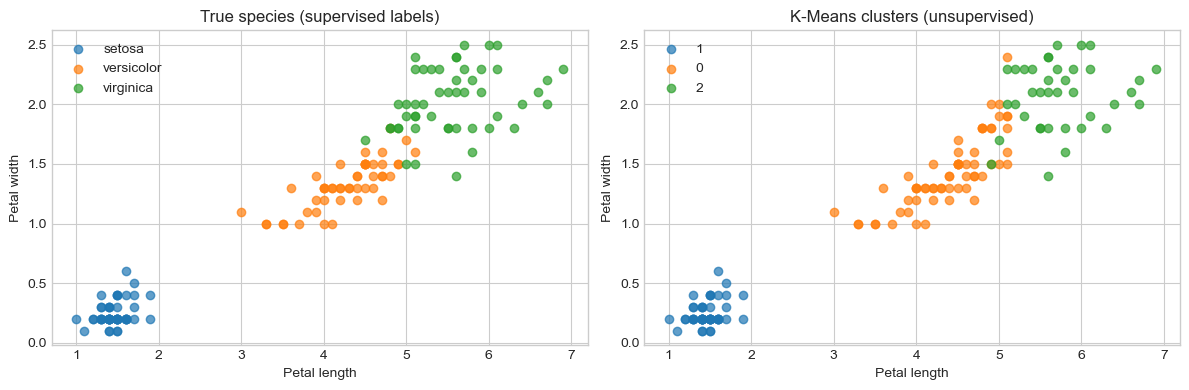

In [4]:
# Create k-Means with 3 clusters (same as number of iris species, but labels not used)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Fit only on X and assign each flower to cluster 0, 1, or 2
clusters = kmeans.fit_predict(X)

# Add discovered cluster IDs back to our DataFrame (DataFrame (two-dimensional labeled data table)) for comparison
df_iris["cluster"] = clusters

# Explain what unsupervised output looks like (no species names used in training)
print("Unsupervised result — algorithm invented its own group IDs (0, 1, 2):")

# Show petal measurements with both true species and discovered clusters
display(df_iris[["petal length (cm)", "petal width (cm)", "species", "cluster"]].head(10))

# Create side-by-side plots: true labels vs unsupervised clusters
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loop over two comparison views (supervised truth vs unsupervised clusters)
for name, ax, color_col in [("True species (supervised labels)", axes[0], "species"),

                             ("K-Means clusters (unsupervised)", axes[1], "cluster")]:

    # Draw one color per group in the current column
    for group in df_iris[color_col].unique():

        # Filter rows belonging to this group only
        subset = df_iris[df_iris[color_col] == group]

        # Plot petal length vs width to visualize separation
        ax.scatter(subset["petal length (cm)"], subset["petal width (cm)"], label=str(group), alpha=0.7)

    # Label x-axis for readability
    ax.set_xlabel("Petal length")

    # Label y-axis for readability
    ax.set_ylabel("Petal width")

    # Title each subplot to show what is being compared
    ax.set_title(name)

    # Show legend identifying groups
    ax.legend()

# Prevent subplot labels from overlapping
plt.tight_layout()

# Render the comparison figure
plt.show()



**Takeaway:** Unsupervised learning found 3 groups that roughly match the 3 species — **without ever seeing species names** during training.


---

## 3. Strengths and Weaknesses

### Supervised Learning

| Strengths | Weaknesses |
|-----------|------------|
| Clear goal: minimize prediction error | Needs lots of **labeled** data (expensive to create) |
| Easy to measure performance (accuracy, RMSE (Root Mean Squared Error)) | Can **overfit** (memorize training data) |
| Works well when labels are reliable | Struggles when data changes over time (**data drift**) |
| Mature, well-understood algorithms | High-dimensional data needs careful feature work |

### Unsupervised Learning

| Strengths | Weaknesses |
|-----------|------------|
| Works on **unlabeled** data (most real-world data!) | No single "correct answer" to compare against |
| Discovers hidden patterns humans might miss | Results can be hard to interpret |
| Helps with preprocessing (PCA (Principal Component Analysis), feature learning) | Must choose parameters (e.g., number of clusters) |
| Enables anomaly detection and segmentation | Evaluation is often subjective |

### Key terms

| Term | Meaning |
|------|--------|
| **Overfitting** | Model memorizes training data but fails on new data |
| **Underfitting (model too simple)** | Model is too simple to capture real patterns |
| **Generalization (good performance on new data)** | Performing well on unseen data |
| **Data drift** | Data distribution changes over time (e.g., new fraud patterns) |


In [5]:
# Use only 40 training samples to make overfitting easier to demonstrate
X_small, y_small = X[:40], y[:40]

# Shallow tree: limited depth reduces overfitting risk
tree_simple = DecisionTreeClassifier(max_depth=2, random_state=42)

# Deep tree: no depth limit can memorize small training set
tree_overfit = DecisionTreeClassifier(max_depth=None, random_state=42)

# Train both trees and compare train vs full-dataset test performance
for name, model in [("Simple tree (depth=2)", tree_simple), ("Deep tree (overfitting risk)", tree_overfit)]:

    # Fit tree on the small training subset
    model.fit(X_small, y_small)

    # Accuracy on training data (often high if overfitting)
    train_acc = accuracy_score(y_small, model.predict(X_small))

    # Accuracy on all data (reveals poor generalization when overfitting)
    test_acc = accuracy_score(y, model.predict(X))

    # Print side-by-side train/test accuracy for each tree
    print(f"{name}: train={train_acc:.0%}, test={test_acc:.0%}")



Simple tree (depth=2): train=100%, test=33%
Deep tree (overfitting risk): train=100%, test=33%


---

## 4. How Unsupervised Learning Improves Supervised Solutions

Chapter 1 explains **six problems** where unsupervised methods help:

| Problem | What it means | Unsupervised help |
|---------|---------------|-------------------|
| **1. Insufficient labeled data** | Not enough examples with answers | Cluster or pre-train on large unlabeled data |
| **2. Overfitting** | Model too complex for data size | Dimensionality reduction, regularization via fewer features |
| **3. Curse of dimensionality** | Too many features; data becomes sparse | PCA (Principal Component Analysis), feature selection |
| **4. Feature engineering** | Creating useful inputs is hard | Autoencoders (Autoencoder neural networks) learn features automatically (Ch. (Chapter) 7–8) |
| **5. Outliers** | Rare unusual points | Anomaly detection flags them (Ch. (Chapter) 4) |
| **6. Data drift** | Patterns change over time | Monitor clusters/distributions for shifts |


### 4.1 Curse of Dimensionality — PCA (Principal Component Analysis) demo

**Curse of dimensionality:** As features increase, data points spread out in high-dimensional space and become hard to compare.

**PCA (Principal Component Analysis):** An unsupervised technique that compresses many features into fewer while keeping most information.


Original features: 4
Reduced to: 2 principal components
Variance retained: 95.8%


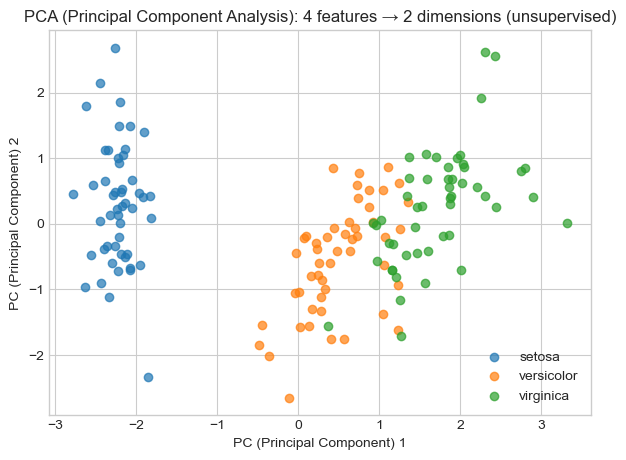

In [6]:
# Create a scaler to standardize features to mean=0 and std (standard deviation)=1
scaler = StandardScaler()

# Fit scaler on X and transform features so PCA (Principal Component Analysis) is not biased by units
X_scaled = scaler.fit_transform(X)

# Configure PCA (Principal Component Analysis) to compress data down to 2 components for plotting
pca = PCA(n_components=2)

# Learn principal directions and project data into 2D (two-dimensional) space
X_2d = pca.fit_transform(X_scaled)

# Show how many input features we started with
print(f"Original features: {X.shape[1]}")

# Show how many dimensions PCA (Principal Component Analysis) produced
print(f"Reduced to: {X_2d.shape[1]} principal components")

# Show how much information was kept after compression
print(f"Variance retained: {pca.explained_variance_ratio_.sum():.1%}")

# Start a new figure for the PCA (Principal Component Analysis) scatter plot
plt.figure(figsize=(7, 5))

# Plot each species with a different color in 2D (two-dimensional) PCA (Principal Component Analysis) space
for i, species in enumerate(target_names):

    # Boolean mask selects rows for one species at a time
    mask = y == i

    # Scatter plot using first and second principal components
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=species, alpha=0.7)

# Name the x-axis as first principal component
plt.xlabel("PC (Principal Component) 1")

# Name the y-axis as second principal component
plt.ylabel("PC (Principal Component) 2")

# Title explains this is unsupervised dimensionality reduction
plt.title("PCA (Principal Component Analysis): 4 features → 2 dimensions (unsupervised)")

# Add legend for species colors
plt.legend()

# Display the PCA (Principal Component Analysis) visualization
plt.show()



### 4.2 Outliers — simple anomaly detection idea

An **outlier** is a data point very different from the majority. Unsupervised methods can flag them without labeled "fraud" examples.


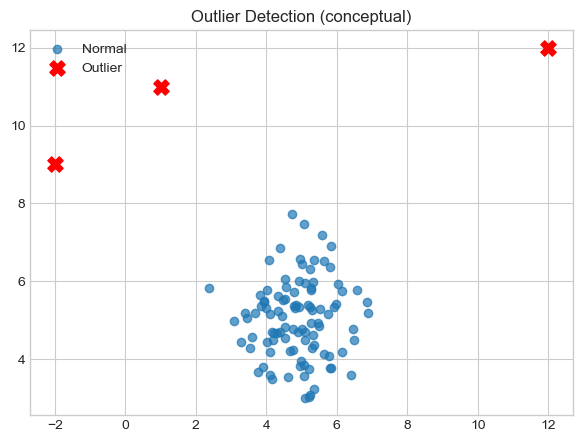

Detected 3 outliers out of 103 points


In [7]:
# Fix random seed so the synthetic outlier demo is reproducible
np.random.seed(42)

# Generate 100 normal points clustered around (5, 5)
normal = np.random.normal(loc=5, scale=1, size=(100, 2))

# Add 3 obvious outlier points far from the main cluster
outliers = np.array([[12, 12], [1, 11], [-2, 9]])

# Stack normal and outlier rows into one dataset
data = np.vstack([normal, outliers])

# Compute absolute Z-scores (Z-scores (standard scores)): how many std devs (standard deviation units) each point is from the mean
z_scores = np.abs((data - data.mean(axis=0)) / data.std(axis=0))

# Flag as outlier if any feature Z-score (Z-score (standard score)) exceeds 2 (simple rule)
is_outlier = z_scores.max(axis=1) > 2

# Create plot for normal vs outlier points
plt.figure(figsize=(7, 5))

# Plot normal points in default color
plt.scatter(data[~is_outlier, 0], data[~is_outlier, 1], label="Normal", alpha=0.7)

# Highlight outliers in red with X markers
plt.scatter(data[is_outlier, 0], data[is_outlier, 1], label="Outlier", color="red", s=120, marker="X")

# Title for the anomaly detection concept demo
plt.title("Outlier Detection (conceptual)")

# Show which points are normal vs outlier
plt.legend()

# Render the scatter plot
plt.show()

# Report how many outliers the simple rule detected
print(f"Detected {is_outlier.sum()} outliers out of {len(data)} points")



---

## 5. Supervised Algorithms (Chapter 1 Overview)

The book groups supervised algorithms into three families. Below: what each does + a tiny example.


### 5.1 Linear Methods

| Algorithm | Task | Idea |
|-----------|------|------|
| **Linear Regression (linear numeric prediction)** | Predict a number | Fit a straight line: y = mx + b |
| **Logistic Regression (linear classification)** | Classify into categories | Fit a curve that outputs probabilities |


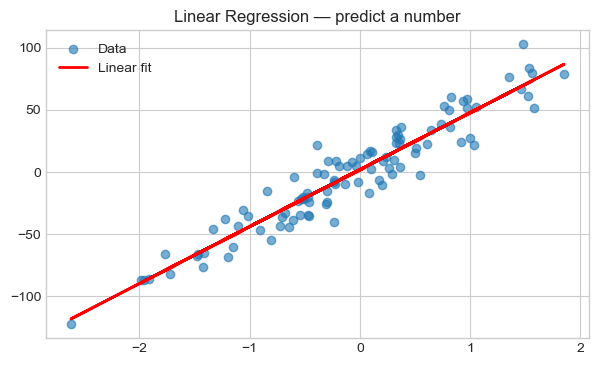

RMSE (Root Mean Squared Error): 13.25


In [8]:
# Create synthetic regression data: 100 points, 1 feature, with noise
X_reg, y_reg = make_regression(n_samples=100, n_features=1, noise=15, random_state=42)

# Initialize ordinary least-squares linear regression model
lr = LinearRegression()

# Fit a straight line that best predicts y from x
lr.fit(X_reg, y_reg)

# Generate predictions on the same data to visualize the fitted line
y_reg_pred = lr.predict(X_reg)

# Create figure for regression scatter + line plot
plt.figure(figsize=(7, 4))

# Plot raw data points
plt.scatter(X_reg, y_reg, alpha=0.6, label="Data")

# Overlay fitted regression line in red
plt.plot(X_reg, y_reg_pred, color="red", linewidth=2, label="Linear fit")

# Title clarifies this is numeric prediction (regression)
plt.title("Linear Regression — predict a number")

# Distinguish data points from fitted line
plt.legend()

# Show the regression visualization
plt.show()

# Compute root mean squared error as a regression error metric
rmse = np.sqrt(mean_squared_error(y_reg, y_reg_pred))

# Print RMSE (Root Mean Squared Error) so learners can quantify fit quality
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")



In [9]:
# Create another logistic regression model for iris classification
log_reg = LogisticRegression(max_iter=200)

# Train on labeled training split from earlier supervised example
log_reg.fit(X_train, y_train)

# Evaluate classification accuracy on held-out test set
print(f"Logistic Regression accuracy: {accuracy_score(y_test, log_reg.predict(X_test)):.2%}")



Logistic Regression accuracy: 100.00%


### 5.2 Neighborhood-Based Methods

| Algorithm | Idea |
|-----------|------|
| **k-Nearest Neighbors (k-NN (k-Nearest Neighbors))** | Classify a point by majority vote of its k closest neighbors |

**Key term — distance metric (similarity measure):** How "close" two points are (usually Euclidean distance).


In [10]:
# Create k-NN (k-Nearest Neighbors) classifier that votes using 5 nearest training neighbors
knn = KNeighborsClassifier(n_neighbors=5)

# Train by storing training data (k-NN (k-Nearest Neighbors) is a lazy learner)
knn.fit(X_train, y_train)

# Measure test accuracy to compare with other supervised algorithms
print(f"k-NN (k=5) accuracy: {accuracy_score(y_test, knn.predict(X_test)):.2%}")



k-NN (k=5) accuracy: 100.00%


### 5.3 Tree-Based Methods

| Algorithm | Idea |
|-----------|------|
| **Decision Tree (tree-based classifier)** | Ask yes/no questions to split data (like a flowchart) |
| **Bagging (Bootstrap Aggregating)** | Train many trees on random subsets, average votes |
| **Random Forest (ensemble of bagged trees)** | Bagging (Bootstrap Aggregating) + random feature subsets at each split |
| **Boosting (Boosting ensemble method)** | Train trees sequentially; each fixes previous errors |

**Key terms:**
- **Ensemble (ensemble learning):** Combining multiple models for better results
- **Hyperparameter (tunable model setting):** A setting you choose before training (e.g., tree depth, k in k-NN (k-Nearest Neighbors))


In [11]:
# Dictionary of tree-based supervised models to compare in one loop
models = {

    # Single decision tree with limited depth to reduce overfitting
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42),

    # Bagging (Bootstrap Aggregating): many trees trained on bootstrap samples
    "Bagging": BaggingClassifier(DecisionTreeClassifier(), n_estimators=25, random_state=42),

    # Random forest: bagging plus random feature subsets at each split
    "Random Forest": RandomForestClassifier(n_estimators=25, random_state=42),

    # Gradient boosting: trees added sequentially to fix prior errors
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50, random_state=42),

}

# Header for the comparison table printed below
print("Supervised algorithm comparison (Iris dataset):")

# Train and evaluate each model using the same train/test split
for name, model in models.items():

    # Fit model on training features and labels
    model.fit(X_train, y_train)

    # Compute accuracy on unseen test data
    acc = accuracy_score(y_test, model.predict(X_test))

    # Print model name and accuracy aligned for easy reading
    print(f"  {name:20s} → {acc:.2%}")



Supervised algorithm comparison (Iris dataset):
  Decision Tree        → 100.00%
  Bagging              → 100.00%
  Random Forest        → 100.00%
  Gradient Boosting    → 100.00%


---

## 6. Unsupervised Algorithms (Chapter 1 Overview)

The book organizes unsupervised methods into four categories. We preview each with terms and a simple demo where possible.


### 6.1 Dimensionality Reduction

Reduce the number of features while keeping structure.

| Method | Type | Idea |
|--------|------|------|
| **PCA (Principal Component Analysis)** | Linear projection | Find directions of maximum variance |
| **SVD (Singular Value Decomposition)** | Linear algebra | Matrix factorization (related to PCA (Principal Component Analysis)) |
| **Random Projection (approximate linear reduction)** | Linear | Fast approximate reduction using random matrices |
| **Isomap (Isometric Mapping)** | Manifold learning | Preserve geodesic distances on curved surfaces |
| **t-SNE (t-Distributed Stochastic Neighbor Embedding)** | Manifold learning | Great for 2D (two-dimensional) visualization of clusters |
| **Dictionary Learning (sparse representation learning)** | Sparse coding (representing data with few active coefficients) | Represent data as combinations of basis patterns |

**Key terms:**
- **Linear projection:** Flatten data onto straight directions
- **Manifold learning:** Data lies on a curved lower-dimensional surface embedded in high-D (high-dimensional) space


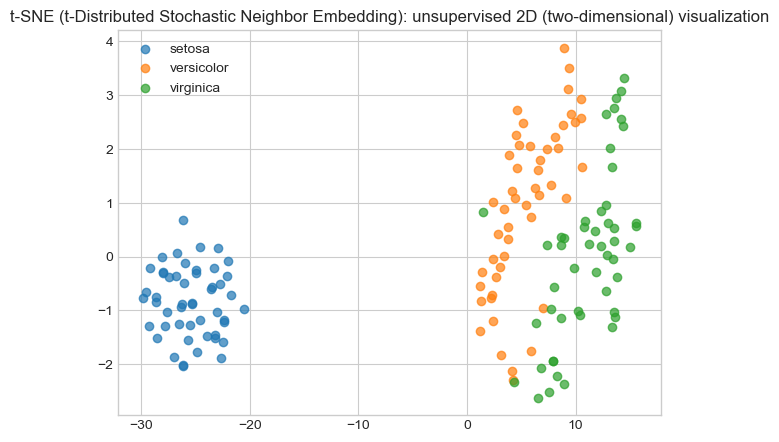

In [12]:
# Configure t-SNE (t-Distributed Stochastic Neighbor Embedding) to map high-dimensional data into 2D (two-dimensional) for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=30)

# Run t-SNE (t-Distributed Stochastic Neighbor Embedding) on scaled iris data (unsupervised — labels not passed in)
X_tsne = tsne.fit_transform(X_scaled)

# Create figure for t-SNE (t-Distributed Stochastic Neighbor Embedding) scatter plot
plt.figure(figsize=(7, 5))

# Color points by true species to see if unsupervised structure matches reality
for i, species in enumerate(target_names):

    # Select rows belonging to one species
    mask = y == i

    # Plot t-SNE (t-Distributed Stochastic Neighbor Embedding) coordinates for that species
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=species, alpha=0.7)

# Title notes this is an unsupervised visualization technique
plt.title("t-SNE (t-Distributed Stochastic Neighbor Embedding): unsupervised 2D (two-dimensional) visualization")

# Identify species in the legend
plt.legend()

# Display t-SNE (t-Distributed Stochastic Neighbor Embedding) plot
plt.show()



### 6.2 Clustering

Group similar data points together.

| Algorithm | Idea | Key term |
|-----------|------|----------|
| **k-Means** | Partition into k groups around centroids | **Centroid (cluster center):** center of a cluster |
| **Hierarchical Clustering (nested cluster tree)** | Build a tree of nested clusters | **Dendrogram (hierarchical cluster tree):** tree diagram of merges |
| **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** | Dense regions = clusters; sparse = noise | **Density-based (density-connected groups):** shape-flexible clustering |


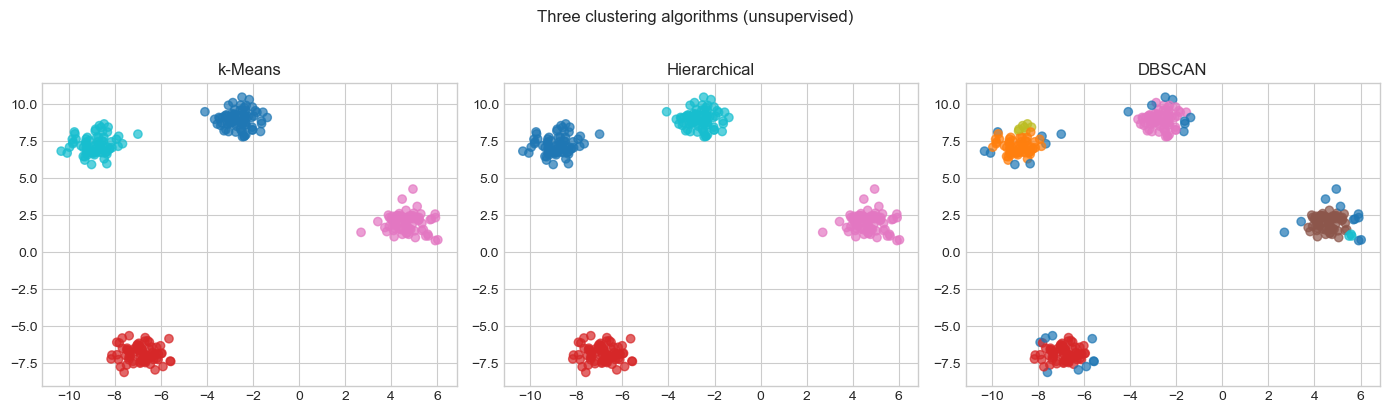

In [13]:
# Generate synthetic 2D (two-dimensional) blob data with 4 well-separated clusters
X_blob, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.6, random_state=42)

# Create 1 row x 3 columns of subplots for algorithm comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Compare k-Means, hierarchical clustering, and DBSCAN (Density-Based Spatial Clustering of Applications with Noise) on the same data
for ax, model, title in [

    # Left plot: centroid-based partitioning
    (axes[0], KMeans(n_clusters=4, random_state=42, n_init=10), "k-Means"),

    # Middle plot: agglomerative hierarchical clustering
    (axes[1], AgglomerativeClustering(n_clusters=4), "Hierarchical"),

    # Right plot: density-based clustering (can find arbitrary shapes)
    (axes[2], DBSCAN(eps=0.4, min_samples=5), "DBSCAN"),

]:

    # Fit clustering model and get cluster label per point
    labels = model.fit_predict(X_blob)

    # Scatter points colored by assigned cluster
    ax.scatter(X_blob[:, 0], X_blob[:, 1], c=labels, cmap="tab10", alpha=0.7)

    # Subplot title shows algorithm name
    ax.set_title(title)

# Overall title above all three clustering plots
plt.suptitle("Three clustering algorithms (unsupervised)", y=1.02)

# Adjust spacing so titles and labels do not overlap
plt.tight_layout()

# Show all three clustering results side by side
plt.show()



### 6.3 Feature Extraction

| Method | Idea |
|--------|------|
| **Autoencoder (autoencoder neural network)** | Neural network that compresses input and reconstructs it — the compressed layer becomes new features |
| **Supervised feedforward network** | Can also learn features, but needs labels |

> **Autoencoders (Autoencoder neural networks)** are covered hands-on in Chapters 7–8. Think of them as a "data zipper": compress → learn → unzip.


### 6.4 Unsupervised Deep Learning

Advanced neural network methods introduced in later chapters:

| Method | Abbreviation | Purpose |
|--------|--------------|--------|
| **Unsupervised pretraining** | — | Train layers on unlabeled data before fine-tuning with labels |
| **Restricted Boltzmann Machine** | RBM (Restricted Boltzmann Machine) | Learn patterns; used in recommender systems (Ch. (Chapter) 10) |
| **Deep Belief Network** | DBN (Deep Belief Network) | Stack RBMs (Restricted Boltzmann Machines) for hierarchical feature learning (Ch. (Chapter) 11) |
| **Generative Adversarial Network** | GAN (Generative Adversarial Network) | Generator creates fake data; discriminator tries to detect fakes (Ch. (Chapter) 12) |

**Key term — generative model (data-generating model):** A model that can **create new data** similar to what it learned.


---

## 7. Successful Applications (Chapter 1)

### 7.1 Anomaly Detection

Find rare events that differ from normal behavior.

**Examples:** Credit card fraud, network intrusions, equipment failure, disease outbreaks.

**Why unsupervised?** Fraud is rare — we often lack enough labeled fraud examples.


### 7.2 Group Segmentation

Divide users/customers into distinct groups based on behavior — **without** predefined categories.

**Examples:**
- Marketing: budget shoppers vs. premium buyers
- Lending: borrower risk profiles (Chapter 6 uses Lending Club data)
- Streaming: music/movie taste clusters

**Key terms:**
- **Segment:** A group of similar users
- **Homogeneous:** Members within a group are alike
- **Distinct:** Groups are different from each other


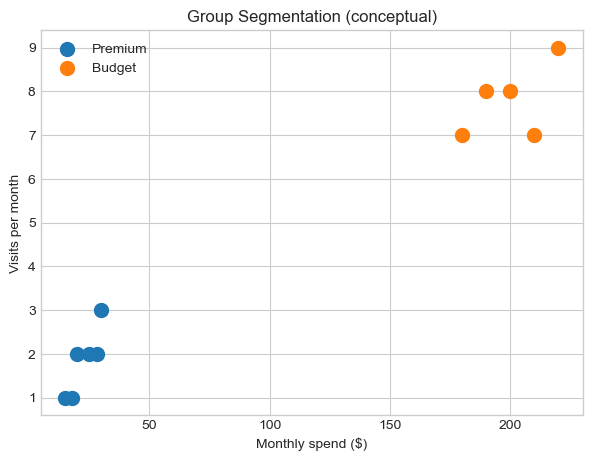

,monthly_spend,visits_per_month,segment,segment_label
0,25,2,1,Premium
1,30,3,1,Premium
2,28,2,1,Premium
3,200,8,0,Budget
4,180,7,0,Budget
5,220,9,0,Budget
6,15,1,1,Premium
7,20,2,1,Premium
8,18,1,1,Premium
9,190,8,0,Budget


In [14]:
# Build a small synthetic customer dataset with spend and visit behavior
customers = pd.DataFrame({

    # Monthly spend in dollars for each customer
    "monthly_spend": [25, 30, 28, 200, 180, 220, 15, 20, 18, 190, 210],

    # Store visit frequency per month for each customer
    "visits_per_month": [2, 3, 2, 8, 7, 9, 1, 2, 1, 8, 7],

})

# Run k-Means to discover 2 customer segments without predefined labels
seg = KMeans(n_clusters=2, random_state=42, n_init=10)

# Add numeric cluster IDs (0 or 1) to the customer table
customers["segment"] = seg.fit_predict(customers)

# Map cluster numbers to business-friendly segment names
customers["segment_label"] = customers["segment"].map({0: "Budget", 1: "Premium"})

# Create scatter plot of customer segments
plt.figure(figsize=(7, 5))

# Plot each segment with a different color
for label in customers["segment_label"].unique():

    # Filter customers in the current segment
    subset = customers[customers["segment_label"] == label]

    # Plot spend vs visits for that segment
    plt.scatter(subset["monthly_spend"], subset["visits_per_month"], label=label, s=100)

# x-axis label for spending behavior
plt.xlabel("Monthly spend ($)")

# y-axis label for visit frequency
plt.ylabel("Visits per month")

# Title connects plot to Chapter 1 application: group segmentation
plt.title("Group Segmentation (conceptual)")

# Show Budget vs Premium legend
plt.legend()

# Render segmentation chart
plt.show()

# Display final table with assigned segments for each customer
display(customers)



---

## 8. Glossary — All Chapter 1 Terms

| Term | One-line definition |
|------|---------------------|
| **Supervised learning** | Learn from labeled data to predict outputs |
| **Unsupervised learning** | Find patterns in unlabeled data |
| **Reinforcement learning** | Learn actions via rewards and penalties |
| **Feature** | Input variable (column in your dataset) |
| **Label** | Target variable (the answer) |
| **Classification (predicting categories)** | Predict a category |
| **Regression (predicting numeric values)** | Predict a number |
| **Clustering (unsupervised grouping)** | Group similar points without labels |
| **Dimensionality reduction** | Reduce number of features |
| **PCA (Principal Component Analysis)** | Principal Component Analysis — linear dimensionality reduction |
| **Manifold learning (nonlinear structure learning)** | Nonlinear dimensionality reduction (t-SNE (t-Distributed Stochastic Neighbor Embedding), Isomap (Isometric Mapping)) |
| **Overfitting (memorizing training data)** | Model memorizes training data |
| **Curse of dimensionality** | High dimensions make data sparse and hard to compare |
| **Feature engineering (creating input features)** | Creating useful input features |
| **Outlier / Anomaly** | Unusual data point |
| **Data drift** | Data distribution changes over time |
| **k-Means** | Clustering by k centroids |
| **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** | Density-based clustering |
| **Autoencoder (autoencoder neural network)** | Neural network for compression and feature learning |
| **RBM (Restricted Boltzmann Machine) / DBN (Deep Belief Network) / GAN (Generative Adversarial Network)** | Deep unsupervised neural architectures |
| **Anomaly detection (outlier detection)** | Finding rare unusual events |
| **Group segmentation (customer/user clustering)** | Dividing users into behavioral clusters |
| **Ensemble (ensemble learning)** | Combining multiple models |
| **Hyperparameter (tunable model setting)** | Model setting chosen before training |


---

## 9. Chapter 1 Summary

```
Machine Learning
├── Supervised (has labels)     → predict Y (label) from X (features)
├── Unsupervised (no labels)    → discover structure in X (features)  ← THIS COURSE
└── Reinforcement (rewards)     → learn optimal actions

Unsupervised helps supervised when:
  • not enough labels  • overfitting  • too many features
  • hard feature engineering  • outliers  • data drift

Main unsupervised tasks:
  • Clustering (k-Means (k-Means clustering by k centroids), DBSCAN (Density-Based Spatial Clustering of Applications with Noise), hierarchical (agglomerative clustering))
  • Dimensionality reduction (PCA (Principal Component Analysis), t-SNE (t-Distributed Stochastic Neighbor Embedding))
  • Feature extraction (autoencoders)
  • Deep unsupervised (RBM (Restricted Boltzmann Machine), DBN (Deep Belief Network), GAN (Generative Adversarial Network))

Key applications:
  • Anomaly detection (fraud, failures)
  • Group segmentation (customers, borrowers)
```

### What's next?

**Chapter 2** walks through a complete end-to-end supervised ML (Machine Learning) project (environment setup, data prep, model training, evaluation, and ensembling). That project framework will be reused throughout the book.

---

### Practice questions

1. You have 1 million emails but only 500 are labeled spam/not-spam. Is this a supervised or unsupervised problem? How could both approaches help?
2. Why might PCA (Principal Component Analysis) help before training a classifier on data with 500 features?
3. Name one business use case for clustering and one for anomaly detection.
4. What is the difference between a **feature** and a **label**?
5. Why is evaluating unsupervised models harder than supervised ones?
